# Pipeline consolidado — Predicción de matrícula universitaria

Notebook limpio con el pipeline final validado: carga de datos, stage1, feature engineering, diagnóstico de leakage, split temporal corregido, encoding y entrenamiento de 4 modelos (Regresión Logística, Random Forest, LightGBM, XGBoost).

**Decisiones clave documentadas:**
- Se excluye el join con `df_colegios` (generaba fan-out 11.6M → 19.3M filas, y `COLEGIO_TIPO` ya existe en el raw).
- Se excluyen las variables `_ES_NULO` y se filtra el dataset de modelado por sesgo de captura de datos (campañas 2022-2023 excluidas).
- Se excluyen `CARRERA_EST` y `DEPARTAMENTO` del modelo (introducían inestabilidad/overfitting en los árboles).
- Modelo ganador: Regresión Logística.

## 1. Imports y carga de datos

In [1]:
import polars as pl
import pandas as pd
import numpy as np
from datetime import datetime

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score, classification_report

pl.Config.set_tbl_rows(30)

polars.config.Config

## 0. Retomar desde checkpoint (opcional)

Si ya corriste el pipeline completo una vez, puedes saltar las secciones 1-6
y cargar directamente el checkpoint que necesites. Ejecuta SOLO la celda
correspondiente al punto donde quieras continuar, en vez de las secciones 1-6.

- `stage1.parquet` -> retomar desde el inicio de Feature Engineering (seccion 3)
- `stage2.parquet` -> retomar desde Features finales / Split (seccion 5-6)
- `train_filtrado.parquet` / `test_filtrado.parquet` -> retomar directo en
  Imputacion / Encoding / Modelos (seccion 7 en adelante)

In [ ]:
import os
os.makedirs("checkpoints", exist_ok=True)

# Descomenta SOLO la opcion que necesites para retomar sin recalcular todo:

# Opcion A -- retomar desde stage1 (saltar seccion 2)
# df_prospectos_stage1 = pl.scan_parquet("checkpoints/stage1.parquet")

# Opcion B -- retomar desde stage2 (saltar secciones 2 y 3)
# df_prospectos_stage2 = pl.scan_parquet("checkpoints/stage2.parquet")

# Opcion C -- retomar directo en train/test filtrado (saltar secciones 2-6)
# df_train_filtrado = pl.read_parquet("checkpoints/train_filtrado.parquet")
# df_test_filtrado = pl.read_parquet("checkpoints/test_filtrado.parquet")
# n_neg = df_train_filtrado.filter(pl.col("PM") == 0).select(pl.len()).item()
# n_pos = df_train_filtrado.filter(pl.col("PM") == 1).select(pl.len()).item()
# scale_pos_weight_filt = n_neg / n_pos
# print(f"scale_pos_weight: {scale_pos_weight_filt:.2f}")
# print(
#     f"Train: {len(df_train_filtrado):,}  |  n_pos: {n_pos:,}  |  scale_pos_weight: {scale_pos_weight_filt:.2f}"
# )

scale_pos_weight: 46.71
Train: 2,954,039  |  n_pos: 61,912  |  scale_pos_weight: 46.71


In [3]:
# Ajustar rutas según ubicación real de los archivos
RUTA_PROSPECTOS = "data/REPORTE_PLANO_PROSPECTOS_UTF8.csv"
RUTA_FACULTADES = "data/master_facultades.csv"

df_prospectos_raw = pl.scan_csv(RUTA_PROSPECTOS)
df_facultades = pl.scan_csv(RUTA_FACULTADES, separator=";")  # <- agregar separator

n_filas = df_prospectos_raw.select(pl.len()).collect().item()
n_cols = len(df_prospectos_raw.collect_schema())
print(f"Dimensiones raw: ({n_filas:,}, {n_cols})")

Dimensiones raw: (11,679,400, 24)


## 2. Stage1 — Limpieza base

Join de facultades (validado `m:1`), normalización de `SIN DATO` → null, filtros de rango en `AÑO_EGRESO` y `EDAD`, estandarización de `DEPARTAMENTO`, agrupación dinámica de `FUENTE_ORIGEN` por umbral de positivos mínimos.

**Nota:** se omite el join con `df_colegios` — generaba fan-out (11.6M → 19.3M filas) porque el mismo nombre de colegio aparece con múltiples `COLEGIO_TIPO` en distintas ubicaciones geográficas. `COLEGIO_TIPO` ya existe en el raw y se usa directamente.

In [4]:
# Validar cardinalidad del join antes de aplicarlo
check = (
    df_prospectos_raw.join(
        df_facultades.select(["CARRERA", "CARRERA_EST", "FACULTAD"]).lazy(),
        on="CARRERA", how="left", validate="m:1", suffix="_master",
    )
    .select(pl.len())
    .collect()
)
print("Join facultades válido (m:1), filas:", check.item())

Join facultades válido (m:1), filas: 11679400


In [5]:
# ==========================
# Umbral dinámico para FUENTE_ORIGEN — minimo 30 positivos por categoria
# ==========================
fuentes_validas = (
    df_prospectos_raw
    .with_columns(
        pl.col("FUENTE_ORIGEN")
        .str.replace("Web AdmisiÃ³n Adelantada", "Web Admisión Adelantada")
        .alias("FUENTE_ORIGEN")
    )
    .group_by("FUENTE_ORIGEN")
    .agg(pl.col("PM").sum().alias("n_pm1"))
    .filter(pl.col("n_pm1") >= 30)
    .select("FUENTE_ORIGEN")
    .collect()
    ["FUENTE_ORIGEN"]
    .to_list()
)
print(f"Categorias validas en FUENTE_ORIGEN: {len(fuentes_validas)}")

Categorias validas en FUENTE_ORIGEN: 18


In [6]:
cols_sin_dato = [
    "CARRERA", "FACULTAD", "CARRERA_EST", "COLEGIO_TIPO",
    "DEPARTAMENTO", "PROVINCIA", "DISTRITO",
    "RANGO_EDAD", "RANGO_EGRESO", "GENERO", "COLEGIO",
]

df_prospectos_stage1 = (
    df_prospectos_raw
    # ========================
    # Merge con facultades (m:1 validado)
    # ========================
    .join(
        df_facultades.select(["CARRERA", "CARRERA_EST", "FACULTAD"]).lazy(),
        on="CARRERA", how="left", validate="m:1", suffix="_master",
    )
    .with_columns(
        pl.coalesce([pl.col("FACULTAD_master"), pl.col("FACULTAD")]).alias("FACULTAD")
    )
    .drop("FACULTAD_master")
    # ========================
    # Normalizar SIN DATO -> null en categoricas
    # ========================
    .with_columns([
        pl.when(pl.col(c) == "SIN DATO").then(None).otherwise(pl.col(c)).alias(c)
        for c in cols_sin_dato
    ])
    # ========================
    # AÑO_EGRESO: 0.0 -> null, filtro de rango valido, cast
    # ========================
    .with_columns(
        pl.when(pl.col("AÑO_EGRESO").is_between(1990, 2030))
        .then(pl.col("AÑO_EGRESO"))
        .otherwise(None)
        .cast(pl.Int16)
        .alias("AÑO_EGRESO")
    )
    # ========================
    # DEPARTAMENTO: mayusculas + normalizar tildes inconsistentes
    # ========================
    .with_columns(
        pl.col("DEPARTAMENTO")
        .str.to_uppercase()
        .str.replace_all("Í", "I")
        .str.replace_all("Á", "A")
        .str.replace_all("É", "E")
        .str.replace_all("Ó", "O")
        .str.replace_all("Ú", "U")
        .alias("DEPARTAMENTO")
    )
    # ========================
    # FUENTE_ORIGEN: corregir encoding + agrupar raras (umbral dinamico)
    # ========================
    .with_columns(
        pl.col("FUENTE_ORIGEN")
        .str.replace("Web AdmisiÃ³n Adelantada", "Web Admisión Adelantada")
        .alias("FUENTE_ORIGEN")
    )
    .with_columns(
        pl.when(pl.col("FUENTE_ORIGEN").is_in(fuentes_validas))
        .then(pl.col("FUENTE_ORIGEN"))
        .otherwise(pl.lit("Otros"))
        .alias("FUENTE_ORIGEN")
    )
    # ========================
    # Separar CAMPAÑA
    # ========================
    .with_columns(pl.col("CAMPAÑA").str.split_exact("-", 1).alias("tmp"))
    .with_columns([
        pl.col("tmp").struct.field("field_0").cast(pl.Int16, strict=False).alias("AÑO_CAMPAÑA"),
        pl.col("tmp").struct.field("field_1").cast(pl.Int8, strict=False).alias("SEMESTRE_CAMPAÑA"),
    ])
    .drop("tmp")
    # ========================
    # EDAD valida -> EDAD_AJUSTADA (EDAD original se mantiene intacta)
    # ========================
    .with_columns(
        pl.when((pl.col("EDAD") > 0) & (pl.col("EDAD") < 90))
        .then(pl.col("EDAD"))
        .otherwise(None)
        .cast(pl.Int16)
        .alias("EDAD_AJUSTADA")
    )
)

n_filas_s1 = df_prospectos_stage1.select(pl.len()).collect().item()
print(f"Filas stage1: {n_filas_s1:,} (debe ser igual al raw, sin fan-out)")

Filas stage1: 11,679,400 (debe ser igual al raw, sin fan-out)


In [7]:
# ==========================
# CHECKPOINT -- guardar stage1 en Parquet para retomar sin recalcular
# ==========================
df_prospectos_stage1.collect().write_parquet("checkpoints/stage1.parquet")
print("stage1 guardado en checkpoints/stage1.parquet")

stage1 guardado en checkpoints/stage1.parquet


## 3. Stage2 — Feature Engineering

Imputación de edad vía año de egreso, recálculo de rangos, extracción de variables de fecha, antigüedad del prospecto, agrupación dinámica de `CARRERA_EST`, y corrección de `ES_PROSPECTO_COLEGIO` (bug de nulos en el OR con `FUENTE_ORIGEN`).

In [8]:
anio_actual = datetime.now().year

# ==========================
# Umbral dinamico para CARRERA_EST -- minimo 100 positivos
# ==========================
carreras_validas = (
    df_prospectos_stage1
    .group_by("CARRERA_EST")
    .agg(pl.col("PM").sum().alias("n_pm1"))
    .filter(pl.col("n_pm1") >= 100)
    .select("CARRERA_EST")
    .collect()
    ["CARRERA_EST"]
    .to_list()
)
print(f"Categorias validas en CARRERA_EST: {len(carreras_validas)}")

Categorias validas en CARRERA_EST: 48


In [9]:
df_prospectos_stage2 = (
    df_prospectos_stage1
    # ==========================
    # CARRERA_EST: agrupar raras
    # ==========================
    .with_columns(
        pl.when(pl.col("CARRERA_EST").is_in(carreras_validas))
        .then(pl.col("CARRERA_EST"))
        .otherwise(pl.lit("CARRERA_OTRAS"))
        .alias("CARRERA_EST")
    )
    # ==========================
    # Parsear FECHA_REGISTRO y extraer componentes
    # ==========================
    .with_columns(
        pl.col("FECHA_REGISTRO")
        .str.to_datetime(format="%m/%d/%Y %I:%M:%S %p", strict=False)
        .alias("FECHA_REGISTRO_DT")
    )
    .with_columns([
        pl.col("FECHA_REGISTRO_DT").dt.month().cast(pl.Int8).alias("REG_MES"),
        pl.col("FECHA_REGISTRO_DT").dt.weekday().cast(pl.Int8).alias("REG_DIA_SEMANA"),
        (
            pl.date(
                pl.col("AÑO_CAMPAÑA"),
                pl.when(pl.col("SEMESTRE_CAMPAÑA") == 1).then(1).otherwise(7),
                1,
            )
            - pl.col("FECHA_REGISTRO_DT").dt.date()
        ).dt.total_days().cast(pl.Int16).alias("DIAS_REGISTRO_A_CAMPAÑA"),
    ])
    .with_columns(
        pl.when(pl.col("DIAS_REGISTRO_A_CAMPAÑA") < 0)
        .then(pl.lit(0))
        .otherwise(pl.col("DIAS_REGISTRO_A_CAMPAÑA"))
        .alias("DIAS_REGISTRO_A_CAMPAÑA")
    )
    # ==========================
    # EDAD_AJUSTADA_2 -- imputar nulos con AÑO_EGRESO (acotado a [14,70])
    # ==========================
    .with_columns(
        pl.when(pl.col("EDAD_AJUSTADA").is_not_null())
        .then(pl.col("EDAD_AJUSTADA"))
        .when(pl.col("AÑO_EGRESO").is_not_null())
        .then(
            pl.when((anio_actual - pl.col("AÑO_EGRESO") + 16).is_between(14, 70))
            .then((anio_actual - pl.col("AÑO_EGRESO") + 16).cast(pl.Int16))
            .otherwise(None)
        )
        .otherwise(None)
        .alias("EDAD_AJUSTADA_2")
    )
    # ==========================
    # RANGO_EDAD_2 -- bins alineados con RANGO_EDAD original
    # ==========================
    .with_columns(
        pl.when(pl.col("EDAD_AJUSTADA_2").is_null())
        .then(None)
        .when(pl.col("EDAD_AJUSTADA_2") < 15)
        .then(pl.lit("[Otros]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(15, 17))
        .then(pl.lit("[15 - 17]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(18, 22))
        .then(pl.lit("[18 - 22]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(23, 25))
        .then(pl.lit("[23 - 25]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(26, 30))
        .then(pl.lit("[26 - 30]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(31, 35))
        .then(pl.lit("[31 - 35]"))
        .when(pl.col("EDAD_AJUSTADA_2").is_between(36, 40))
        .then(pl.lit("[36 - 40]"))
        .otherwise(pl.lit("[>40]"))
        .alias("RANGO_EDAD_2")
    )
    # ==========================
    # ES_PROSPECTO_COLEGIO -- corregido: fill_null(False) en cada termino del OR
    # ==========================
    .with_columns(
        (
            (pl.col("EDAD_AJUSTADA_2").is_between(15, 17).fill_null(False))
            | (pl.col("FUENTE_ORIGEN") == "Colegios").fill_null(False)
            | (pl.col("FUENTE_ORIGEN") == "Colegios Admision Adelantada").fill_null(False)
        ).cast(pl.Int8).alias("ES_PROSPECTO_COLEGIO")
    )
    # ==========================
    # ES_VIRTUAL
    # ==========================
    .with_columns(
        (pl.col("CAMPUS") == "VIRTUAL").cast(pl.Int8).alias("ES_VIRTUAL")
    )
    # ==========================
    # CONTEO_LEAD_ID
    # ==========================
    .sort(["LEAD_ID", "AÑO_CAMPAÑA", "SEMESTRE_CAMPAÑA"])
    .with_row_index("idx")
    .with_columns(
        pl.col("idx").rank("ordinal").over("LEAD_ID").cast(pl.UInt32).alias("CONTEO_LEAD_ID")
    )
    .drop("idx")
)

n_filas_s2 = df_prospectos_stage2.select(pl.len()).collect().item()
print(f"Filas stage2: {n_filas_s2:,}")

Filas stage2: 11,679,400


In [10]:
# ==========================
# CHECKPOINT -- guardar stage2 completo en Parquet
# ==========================
df_prospectos_stage2.collect().write_parquet("checkpoints/stage2.parquet")
print("stage2 guardado en checkpoints/stage2.parquet")

stage2 guardado en checkpoints/stage2.parquet


## 4. Diagnóstico de leakage (resumen)

**Hallazgo clave:** las variables `_ES_NULO` (flags de missingness) presentaban IV extremo (6-9) porque la ausencia de datos demográficos correlaciona casi perfectamente con no-conversión: el CRM completa estos campos solo cuando el prospecto avanza en el proceso comercial, no en el primer contacto. Se confirmó con `TOTAL_NULOS`: de 15.47% de conversión con 0 nulos a 0.00% con 3+ nulos simultáneos.

**Decisión:** se excluyen las variables `_ES_NULO` explícitas, y se filtra el dataset de modelado a prospectos con información mínima (`EDAD_AJUSTADA_2` o `RANGO_EGRESO` no nulos), evitando la separación casi perfecta que generaba probabilidades polarizadas (p50=0.97) y modelos no generalizables.

**Segundo hallazgo:** las campañas 2022-2023 retienen solo 17-22% de registros tras el filtro (vs 51-100% en 2024-2026), evidenciando un cambio en el proceso de captura del CRM. Se excluyen del entrenamiento para evitar el sesgo de selección temporal.

**Tercer hallazgo:** `CARRERA_EST` y `DEPARTAMENTO` como categóricas nativas en LightGBM generaban overfitting severo (PR-AUC colapsaba de 0.27 a 0.03-0.05). Se excluyen del set final de 18 features.

In [12]:
# Verificacion rapida del filtro de informacion minima
n_antes = df_prospectos_stage2.select(pl.len()).collect().item()
n_despues = (
    df_prospectos_stage2
    .filter(
        pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null()
    )
    .select(pl.len()).collect().item()
)
print(f"Antes del filtro de informacion minima: {n_antes:,}")
print(f"Despues del filtro: {n_despues:,} ({n_despues/n_antes*100:.1f}% retenido)")

NameError: name 'df_prospectos_stage2' is not defined

## 5. Features finales del modelo (18)

In [13]:
cols_categoricas_final = [
    "BASE_ST", "TIPO_ESTUDIANTE", "CAMPUS", "FUENTE_ORIGEN",
    "FACULTAD", "COLEGIO_TIPO", "RANGO_EGRESO", "UND", "GENERO",
]

cols_numericas_final = [
    # AÑO_CAMPAÑA excluida -- sin varianza en train (solo año 2024),
    # importancia 0.000 en RF, frágil para generalizar a campañas futuras
    "SEMESTRE_CAMPAÑA", "EDAD_AJUSTADA_2",
    "REG_MES", "REG_DIA_SEMANA", "DIAS_REGISTRO_A_CAMPAÑA",
    "ES_PROSPECTO_COLEGIO", "ES_VIRTUAL",
]

cols_modelo_final = cols_categoricas_final + cols_numericas_final + ["RANGO_EDAD_2"]
print(f"Total features: {len(cols_modelo_final)}")
print(cols_modelo_final)

Total features: 17
['BASE_ST', 'TIPO_ESTUDIANTE', 'CAMPUS', 'FUENTE_ORIGEN', 'FACULTAD', 'COLEGIO_TIPO', 'RANGO_EGRESO', 'UND', 'GENERO', 'SEMESTRE_CAMPAÑA', 'EDAD_AJUSTADA_2', 'REG_MES', 'REG_DIA_SEMANA', 'DIAS_REGISTRO_A_CAMPAÑA', 'ES_PROSPECTO_COLEGIO', 'ES_VIRTUAL', 'RANGO_EDAD_2']


## 6. Split temporal corregido

Train: 2024 completo (captura de datos consistente). Test: 2025-2026. Se excluyen 2022-2023 por sesgo de captura de datos en el CRM.

In [14]:
df_train_filtrado = (
    df_prospectos_stage2
    .filter(
        (pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null())
        & (pl.col("AÑO_CAMPAÑA") == 2024)
    )
    .collect()
)

df_test_filtrado = (
    df_prospectos_stage2
    .filter(
        (pl.col("EDAD_AJUSTADA_2").is_not_null() | pl.col("RANGO_EGRESO").is_not_null())
        & (pl.col("AÑO_CAMPAÑA") >= 2025)
    )
    .collect()
)

print(f"Train (2024): {len(df_train_filtrado):,}  -- tasa PM=1: {df_train_filtrado['PM'].mean()*100:.2f}%")
print(f"Test (2025-2026): {len(df_test_filtrado):,}  -- tasa PM=1: {df_test_filtrado['PM'].mean()*100:.2f}%")

NameError: name 'df_prospectos_stage2' is not defined

In [15]:
# ==========================
# CHECKPOINT -- guardar train/test filtrados (pre-imputacion, pre-encoding)
# ==========================
df_train_filtrado.write_parquet("checkpoints/train_filtrado.parquet")
df_test_filtrado.write_parquet("checkpoints/test_filtrado.parquet")
print("train/test filtrados guardados en checkpoints/")

train/test filtrados guardados en checkpoints/


In [16]:
n_neg = df_train_filtrado.filter(pl.col("PM") == 0).select(pl.len()).item()
n_pos = df_train_filtrado.filter(pl.col("PM") == 1).select(pl.len()).item()
scale_pos_weight_filt = n_neg / n_pos
print(f"n_neg: {n_neg:,}  n_pos: {n_pos:,}  scale_pos_weight: {scale_pos_weight_filt:.2f}")

n_neg: 2,892,127  n_pos: 61,912  scale_pos_weight: 46.71


## 7. Imputación para modelos que no manejan nulos nativamente

`EDAD_AJUSTADA_2` aún tiene nulos residuales (registros con `RANGO_EGRESO` pero sin edad). Se imputa con la mediana de train, exclusivamente para Regresión Logística, Random Forest y XGBoost. LightGBM usa la versión sin imputar (maneja nulos nativamente vía categóricas).

In [17]:
mediana_edad = df_train_filtrado["EDAD_AJUSTADA_2"].median()
print(f"Mediana EDAD_AJUSTADA_2 (train): {mediana_edad}")

df_train_imp = df_train_filtrado.with_columns(
    pl.col("EDAD_AJUSTADA_2").fill_null(mediana_edad)
)
df_test_imp = df_test_filtrado.with_columns(
    pl.col("EDAD_AJUSTADA_2").fill_null(mediana_edad)
)

print(df_train_imp["EDAD_AJUSTADA_2"].is_null().sum(), df_test_imp["EDAD_AJUSTADA_2"].is_null().sum())

Mediana EDAD_AJUSTADA_2 (train): 23.0
0 0


## 8. Target encoding (para LR, RF y XGBoost)

Calculado únicamente sobre train, excluyendo `null` del cálculo de categorías para que reciba la media global vía `fill_null` (evita reintroducir el leakage del null como valor numérico extremo).

In [18]:
def calcular_target_encoding(df_train, col, target="PM", smoothing=10):
    media_global = df_train[target].mean()
    stats = (
        df_train
        .filter(pl.col(col).is_not_null())
        .group_by(col)
        .agg([
            pl.len().alias("n"),
            pl.col(target).mean().alias("media_categoria"),
        ])
        .with_columns(
            (
                (pl.col("n") * pl.col("media_categoria") + smoothing * media_global)
                / (pl.col("n") + smoothing)
            ).alias(f"{col}_TE")
        )
        .select([col, f"{col}_TE"])
    )
    return stats, media_global

In [19]:
df_train_te = df_train_imp.clone()
df_test_te = df_test_imp.clone()

for col in cols_categoricas_final:
    stats, media_g = calcular_target_encoding(df_train_imp, col)
    df_train_te = (
        df_train_te.join(stats, on=col, how="left")
        .with_columns(pl.col(f"{col}_TE").fill_null(media_g))
    )
    df_test_te = (
        df_test_te.join(stats, on=col, how="left")
        .with_columns(pl.col(f"{col}_TE").fill_null(media_g))
    )

# RANGO_EDAD_2 tambien se encodea
stats_redad, media_redad = calcular_target_encoding(df_train_imp, "RANGO_EDAD_2")
df_train_te = (
    df_train_te.join(stats_redad, on="RANGO_EDAD_2", how="left")
    .with_columns(pl.col("RANGO_EDAD_2_TE").fill_null(media_redad))
)
df_test_te = (
    df_test_te.join(stats_redad, on="RANGO_EDAD_2", how="left")
    .with_columns(pl.col("RANGO_EDAD_2_TE").fill_null(media_redad))
)

cols_te = [f"{c}_TE" for c in cols_categoricas_final] + ["RANGO_EDAD_2_TE"]
cols_xgb_v2 = cols_te + cols_numericas_final

X_train_te = df_train_te.select(cols_xgb_v2).to_pandas()
y_train_te = df_train_te["PM"].to_pandas()
X_test_te = df_test_te.select(cols_xgb_v2).to_pandas()
y_test_te = df_test_te["PM"].to_pandas()

print("Nulos train:", X_train_te.isnull().sum().sum())
print("Nulos test:", X_test_te.isnull().sum().sum())

Nulos train: 0
Nulos test: 0


## 9. Modelo 1 — Regresión Logística

In [20]:
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_te)
X_test_lr = scaler.transform(X_test_te)

modelo_lr = LogisticRegression(
    class_weight={0: 1, 1: scale_pos_weight_filt},
    max_iter=1000,
    random_state=42,
)
modelo_lr.fit(X_train_lr, y_train_te)

y_proba_lr = modelo_lr.predict_proba(X_test_lr)[:, 1]
pr_auc_lr = average_precision_score(y_test_te, y_proba_lr)
f1_lr = f1_score(y_test_te, modelo_lr.predict(X_test_lr))

print(f"PR-AUC LR: {pr_auc_lr:.4f}")
print(f"F1 LR: {f1_lr:.4f}")
print(classification_report(y_test_te, modelo_lr.predict(X_test_lr)))

PR-AUC LR: 0.3571
F1 LR: 0.1203
              precision    recall  f1-score   support

           0       1.00      0.63      0.78   4237195
           1       0.06      0.97      0.12    110128

    accuracy                           0.64   4347323
   macro avg       0.53      0.80      0.45   4347323
weighted avg       0.97      0.64      0.76   4347323



In [21]:
coeficientes = pd.DataFrame({
    "feature": cols_xgb_v2,
    "coeficiente": modelo_lr.coef_[0],
}).sort_values("coeficiente", ascending=False)
print(coeficientes)

                    feature  coeficiente
5           COLEGIO_TIPO_TE     1.696667
8                 GENERO_TE     1.182871
9           RANGO_EDAD_2_TE     0.896524
7                    UND_TE     0.734928
11          EDAD_AJUSTADA_2     0.715802
6           RANGO_EGRESO_TE     0.675983
0                BASE_ST_TE     0.675331
2                 CAMPUS_TE     0.213112
13           REG_DIA_SEMANA     0.187984
4               FACULTAD_TE     0.175870
1        TIPO_ESTUDIANTE_TE     0.173142
3          FUENTE_ORIGEN_TE     0.042307
12                  REG_MES    -0.015448
16               ES_VIRTUAL    -0.327144
14  DIAS_REGISTRO_A_CAMPAÑA    -0.511067
15     ES_PROSPECTO_COLEGIO    -0.783043
10         SEMESTRE_CAMPAÑA    -1.514530


## 10. Modelo 2 — Random Forest

In [22]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_jobs=-1,
    random_state=42,
)
modelo_rf.fit(X_train_te, y_train_te)

y_proba_rf = modelo_rf.predict_proba(X_test_te)[:, 1]
pr_auc_rf = average_precision_score(y_test_te, y_proba_rf)
f1_rf = f1_score(y_test_te, modelo_rf.predict(X_test_te))

print(f"PR-AUC RF: {pr_auc_rf:.4f}")
print(f"F1 RF: {f1_rf:.4f}")
print(classification_report(y_test_te, modelo_rf.predict(X_test_te)))

PR-AUC RF: 0.5189
F1 RF: 0.1263
              precision    recall  f1-score   support

           0       1.00      0.65      0.79   4237195
           1       0.07      0.96      0.13    110128

    accuracy                           0.66   4347323
   macro avg       0.53      0.81      0.46   4347323
weighted avg       0.98      0.66      0.77   4347323



## 11. Modelo 3 — XGBoost

In [23]:
modelo_xgb = xgb.XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=scale_pos_weight_filt,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="aucpr",
)
modelo_xgb.fit(X_train_te, y_train_te)

y_proba_xgb = modelo_xgb.predict_proba(X_test_te)[:, 1]
pr_auc_xgb = average_precision_score(y_test_te, y_proba_xgb)
f1_xgb = f1_score(y_test_te, modelo_xgb.predict(X_test_te))

print(f"PR-AUC XGBoost: {pr_auc_xgb:.4f}")
print(f"F1 XGBoost: {f1_xgb:.4f}")
print(classification_report(y_test_te, modelo_xgb.predict(X_test_te)))

PR-AUC XGBoost: 0.4889
F1 XGBoost: 0.1332
              precision    recall  f1-score   support

           0       1.00      0.70      0.82   4237195
           1       0.07      0.89      0.13    110128

    accuracy                           0.71   4347323
   macro avg       0.53      0.79      0.48   4347323
weighted avg       0.97      0.71      0.81   4347323



## 12. Modelo 4 — LightGBM 

Usa `df_train_filtrado` / `df_test_filtrado` (sin imputación) ya que LightGBM maneja nulos nativamente.

In [24]:
X_train_lgbm = df_train_filtrado.select(cols_modelo_final).to_pandas()
y_train_lgbm = df_train_filtrado["PM"].to_pandas()
X_test_lgbm = df_test_filtrado.select(cols_modelo_final).to_pandas()
y_test_lgbm = df_test_filtrado["PM"].to_pandas()

cols_cat_lgbm = cols_categoricas_final + ["RANGO_EDAD_2"]
for c in cols_cat_lgbm:
    X_train_lgbm[c] = X_train_lgbm[c].astype("category")
    X_test_lgbm[c] = X_test_lgbm[c].astype("category")

modelo_lgbm = lgb.LGBMClassifier(
    objective="binary",
    class_weight={0: 1, 1: scale_pos_weight_filt},
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)
modelo_lgbm.fit(X_train_lgbm, y_train_lgbm, categorical_feature=cols_cat_lgbm)

y_proba_lgbm = modelo_lgbm.predict_proba(X_test_lgbm)[:, 1]
pr_auc_lgbm = average_precision_score(y_test_lgbm, y_proba_lgbm)
f1_lgbm = f1_score(y_test_lgbm, modelo_lgbm.predict(X_test_lgbm))

print(f"PR-AUC LightGBM: {pr_auc_lgbm:.4f}")
print(f"F1 LightGBM: {f1_lgbm:.4f}")
print(classification_report(y_test_lgbm, modelo_lgbm.predict(X_test_lgbm)))

PR-AUC LightGBM: 0.3739
F1 LightGBM: 0.1093
              precision    recall  f1-score   support

           0       1.00      0.58      0.74   4237195
           1       0.06      0.98      0.11    110128

    accuracy                           0.59   4347323
   macro avg       0.53      0.78      0.42   4347323
weighted avg       0.98      0.59      0.72   4347323



## 13. Tabla comparativa final

In [25]:
resumen = pd.DataFrame([
    {"modelo": "Regresion Logistica", "PR_AUC": pr_auc_lr, "F1": f1_lr},
    {"modelo": "Random Forest", "PR_AUC": pr_auc_rf, "F1": f1_rf},
    {"modelo": "XGBoost", "PR_AUC": pr_auc_xgb, "F1": f1_xgb},
    {"modelo": "LightGBM", "PR_AUC": pr_auc_lgbm, "F1": f1_lgbm},
]).sort_values("PR_AUC", ascending=False)

print(resumen.to_string(index=False))

             modelo   PR_AUC       F1
      Random Forest 0.518889 0.126321
            XGBoost 0.488856 0.133163
           LightGBM 0.373889 0.109265
Regresion Logistica 0.357062 0.120348


## 14. Curva Precision-Recall y Matriz de Confusión — Random Forest

El umbral por defecto (0.5) no es necesariamente el óptimo con desbalance severo.
Se analiza el trade-off completo y se identifica el umbral que maximiza F1.

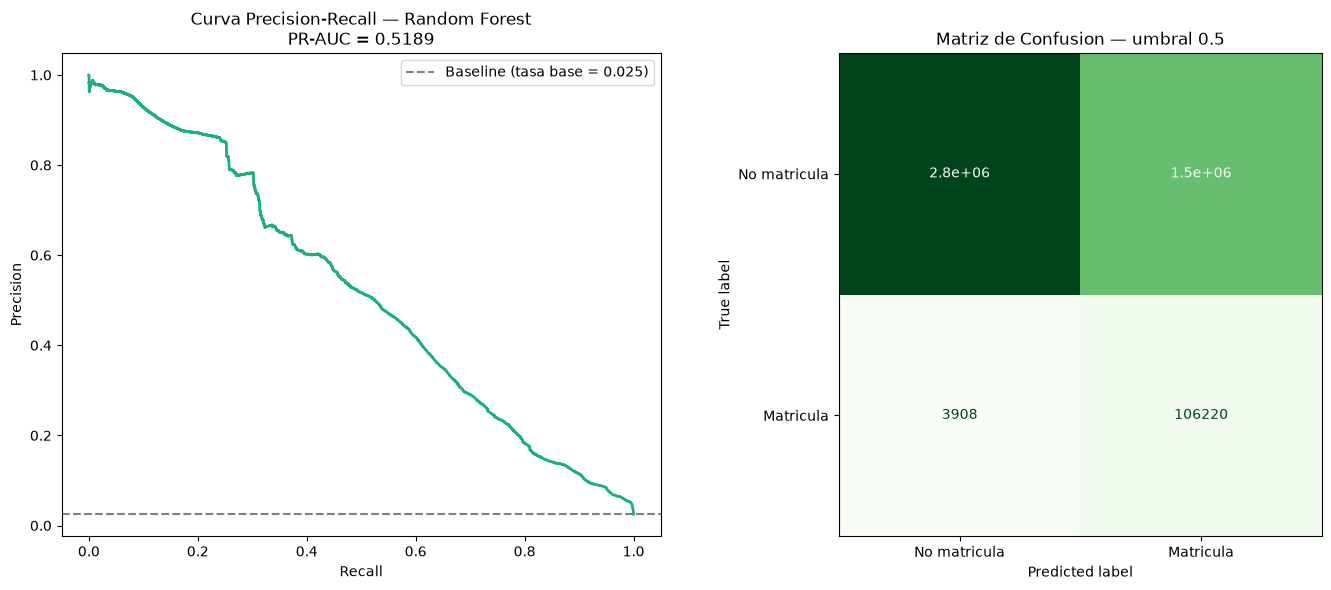

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay

# Curva Precision-Recall
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test_te, y_proba_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Izquierdo: curva PR
axes[0].plot(recall_vals, precision_vals, color="#1baf7a", linewidth=2)
axes[0].axhline(
    y=y_test_te.mean(),
    color="gray", linestyle="--",
    label=f"Baseline (tasa base = {y_test_te.mean():.3f})"
)
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Curva Precision-Recall — Random Forest\nPR-AUC = {pr_auc_rf:.4f}")
axes[0].legend()

# Derecho: matriz de confusion con umbral 0.5
ConfusionMatrixDisplay.from_predictions(
    y_test_te,
    modelo_rf.predict(X_test_te),
    display_labels=["No matricula", "Matricula"],
    cmap="Greens", ax=axes[1], colorbar=False
)
axes[1].set_title("Matriz de Confusion — umbral 0.5")

plt.tight_layout()
plt.savefig("curva_pr_y_confusion_rf.png", dpi=150)
plt.show()

## 15. Optimización del umbral de decisión

Se evalúa el trade-off entre precision y recall para distintos umbrales
y se identifica el punto óptimo según el caso de uso de negocio.

In [28]:
import numpy as np

umbrales_prueba = np.arange(0.05, 0.95, 0.05)
resultados_umbral = []

for u in umbrales_prueba:
    y_pred_u = (y_proba_rf >= u).astype(int)
    n_pred_pos = y_pred_u.sum()
    n_verdaderos_pos = ((y_pred_u == 1) & (y_test_te == 1)).sum()
    n_reales_pos = (y_test_te == 1).sum()

    precision_u = n_verdaderos_pos / n_pred_pos if n_pred_pos > 0 else 0
    recall_u = n_verdaderos_pos / n_reales_pos
    f1_u = (2 * precision_u * recall_u / (precision_u + recall_u)
            if (precision_u + recall_u) > 0 else 0)

    resultados_umbral.append({
        "umbral": round(u, 2),
        "precision": round(precision_u, 4),
        "recall": round(recall_u, 4),
        "f1": round(f1_u, 4),
        "n_predichos_positivos": int(n_pred_pos),
    })

df_umbrales = pd.DataFrame(resultados_umbral)
mejor_umbral = df_umbrales.loc[df_umbrales["f1"].idxmax()]

print(df_umbrales.to_string(index=False))
print(f"\nMejor umbral por F1: {mejor_umbral['umbral']} "
      f"(F1={mejor_umbral['f1']:.4f}, "
      f"Precision={mejor_umbral['precision']:.4f}, "
      f"Recall={mejor_umbral['recall']:.4f})")

 umbral  precision  recall     f1  n_predichos_positivos
   0.05     0.0283  1.0000 0.0550                3893642
   0.10     0.0335  0.9993 0.0648                3288117
   0.15     0.0383  0.9983 0.0737                2874007
   0.20     0.0469  0.9969 0.0896                2340575
   0.25     0.0503  0.9952 0.0958                2178778
   0.30     0.0525  0.9928 0.0997                2082171
   0.35     0.0549  0.9874 0.1039                1982372
   0.40     0.0623  0.9778 0.1171                1729293
   0.45     0.0655  0.9693 0.1226                1630775
   0.50     0.0676  0.9645 0.1263                1571614
   0.55     0.0715  0.9590 0.1330                1477915
   0.60     0.0826  0.9504 0.1520                1267241
   0.65     0.0906  0.9315 0.1652                1131986
   0.70     0.1014  0.9109 0.1825                 989022
   0.75     0.1176  0.8947 0.2079                 838000
   0.80     0.1366  0.8666 0.2359                 698932
   0.85     0.1653  0.8125 0.27

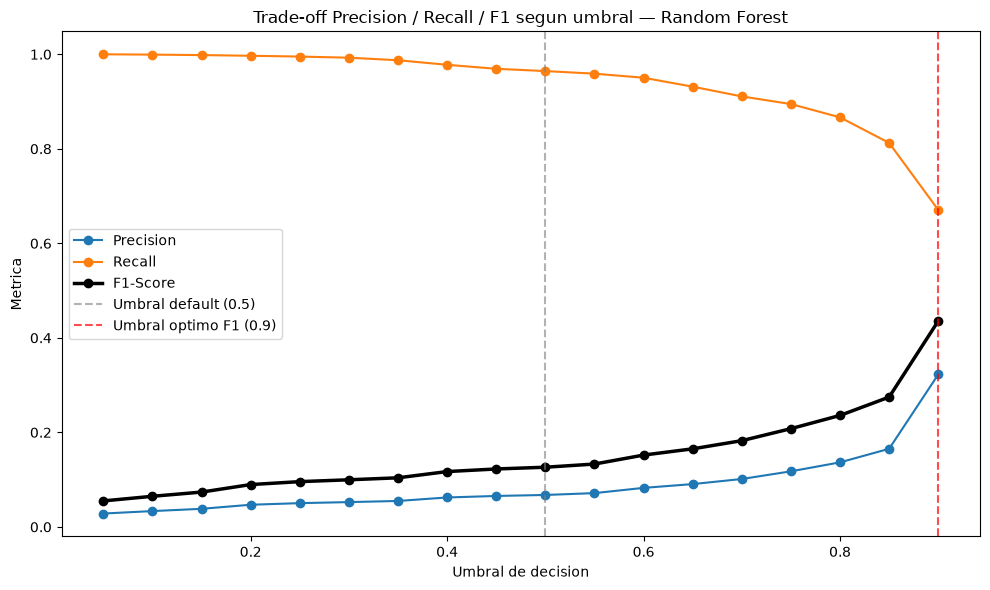

In [29]:
# Grafico de trade-off por umbral
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_umbrales["umbral"], df_umbrales["precision"], label="Precision", marker="o")
ax.plot(df_umbrales["umbral"], df_umbrales["recall"], label="Recall", marker="o")
ax.plot(df_umbrales["umbral"], df_umbrales["f1"], label="F1-Score",
        marker="o", linewidth=2.5, color="black")
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.6, label="Umbral default (0.5)")
ax.axvline(x=mejor_umbral["umbral"], color="red", linestyle="--", alpha=0.7,
           label=f"Umbral optimo F1 ({mejor_umbral['umbral']})")
ax.set_xlabel("Umbral de decision")
ax.set_ylabel("Metrica")
ax.set_title("Trade-off Precision / Recall / F1 segun umbral — Random Forest")
ax.legend()
plt.tight_layout()
plt.savefig("optimizacion_umbral_rf.png", dpi=150)
plt.show()

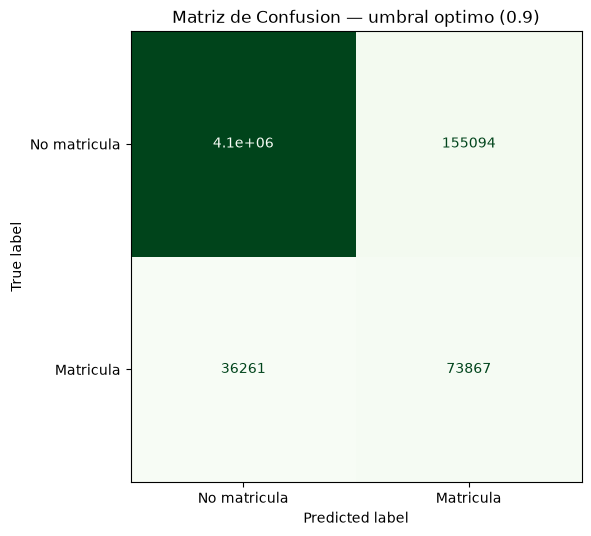


Classification report con umbral optimo:
              precision    recall  f1-score   support

No matricula       0.99      0.96      0.98   4237195
   Matricula       0.32      0.67      0.44    110128

    accuracy                           0.96   4347323
   macro avg       0.66      0.82      0.71   4347323
weighted avg       0.97      0.96      0.96   4347323



In [30]:
# Matriz de confusion con el umbral optimo
umbral_optimo = mejor_umbral["umbral"]
y_pred_optimo = (y_proba_rf >= umbral_optimo).astype(int)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_te, y_pred_optimo,
    display_labels=["No matricula", "Matricula"],
    cmap="Greens", ax=ax, colorbar=False
)
ax.set_title(f"Matriz de Confusion — umbral optimo ({umbral_optimo})")
plt.tight_layout()
plt.savefig("confusion_umbral_optimo_rf.png", dpi=150)
plt.show()

print("\nClassification report con umbral optimo:")
print(classification_report(y_test_te, y_pred_optimo,
                             target_names=["No matricula", "Matricula"]))

## 16. Feature Importance — Random Forest

                feature  importance
        COLEGIO_TIPO_TE    0.248677
        RANGO_EDAD_2_TE    0.199263
             BASE_ST_TE    0.121204
        EDAD_AJUSTADA_2    0.106437
        RANGO_EGRESO_TE    0.097812
DIAS_REGISTRO_A_CAMPAÑA    0.062517
                 UND_TE    0.035715
       FUENTE_ORIGEN_TE    0.027686
     TIPO_ESTUDIANTE_TE    0.026917
              GENERO_TE    0.013767
       SEMESTRE_CAMPAÑA    0.012453
         REG_DIA_SEMANA    0.012291
   ES_PROSPECTO_COLEGIO    0.010463
              CAMPUS_TE    0.008379
                REG_MES    0.007052
             ES_VIRTUAL    0.005069
            FACULTAD_TE    0.004299


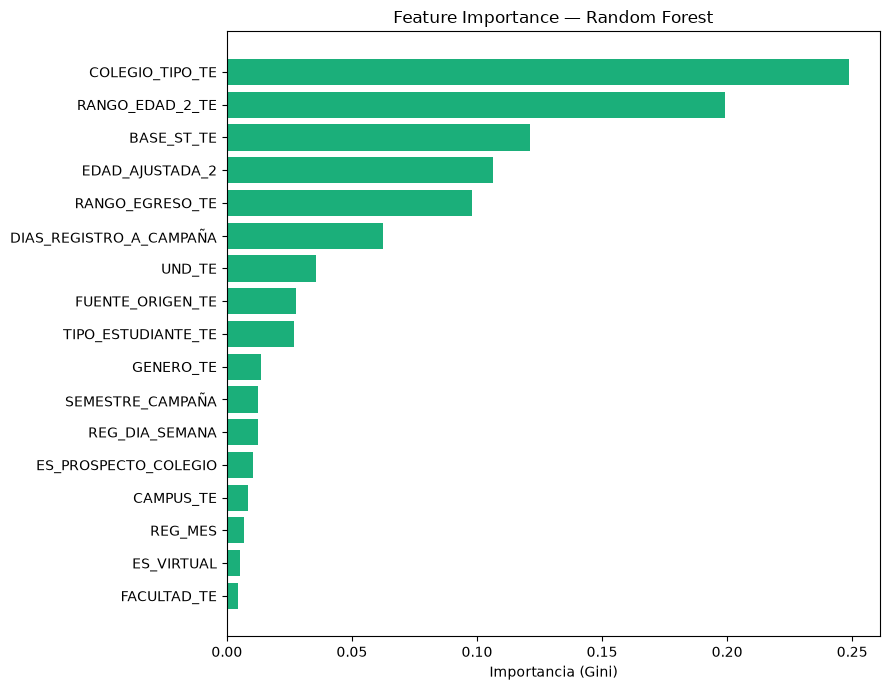

In [31]:
importancias_rf = pd.DataFrame({
    "feature": cols_xgb_v2,
    "importance": modelo_rf.feature_importances_,
}).sort_values("importance", ascending=False)

print(importancias_rf.to_string(index=False))

# Grafico de importancias
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importancias_rf["feature"][::-1],
        importancias_rf["importance"][::-1],
        color="#1baf7a")
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=150)
plt.show()

## 17. Coeficientes — Regresión Logística

                feature  coeficiente
        COLEGIO_TIPO_TE     1.696667
              GENERO_TE     1.182871
        RANGO_EDAD_2_TE     0.896524
                 UND_TE     0.734928
        EDAD_AJUSTADA_2     0.715802
        RANGO_EGRESO_TE     0.675983
             BASE_ST_TE     0.675331
              CAMPUS_TE     0.213112
         REG_DIA_SEMANA     0.187984
            FACULTAD_TE     0.175870
     TIPO_ESTUDIANTE_TE     0.173142
       FUENTE_ORIGEN_TE     0.042307
                REG_MES    -0.015448
             ES_VIRTUAL    -0.327144
DIAS_REGISTRO_A_CAMPAÑA    -0.511067
   ES_PROSPECTO_COLEGIO    -0.783043
       SEMESTRE_CAMPAÑA    -1.514530


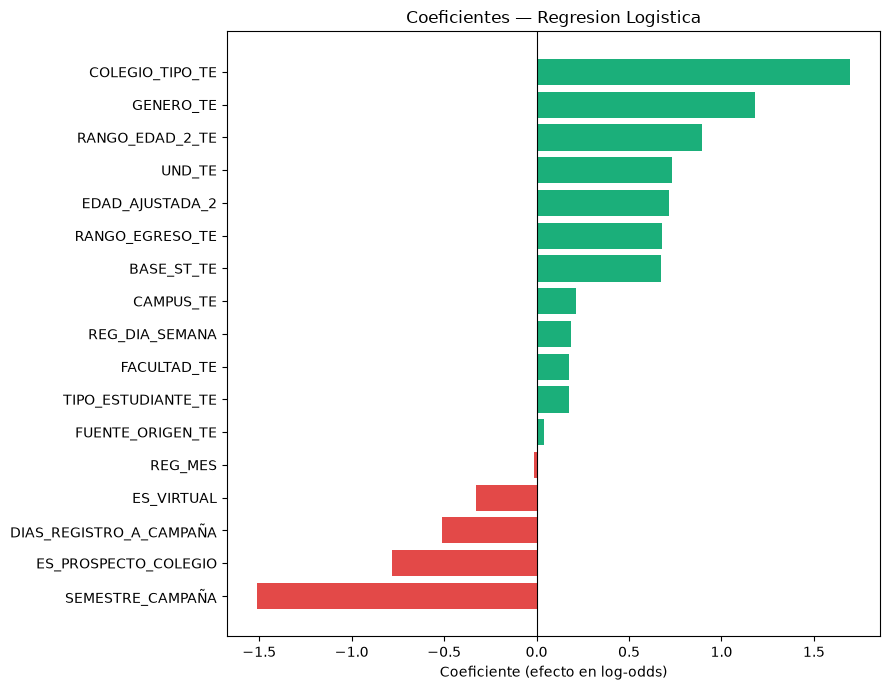

In [32]:
coeficientes = pd.DataFrame({
    "feature": cols_xgb_v2,
    "coeficiente": modelo_lr.coef_[0],
}).sort_values("coeficiente", ascending=False)

print(coeficientes.to_string(index=False))

# Grafico de coeficientes
colores = ["#1baf7a" if v >= 0 else "#e34948" for v in coeficientes["coeficiente"]]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coeficientes["feature"], coeficientes["coeficiente"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (efecto en log-odds)")
ax.set_title("Coeficientes — Regresion Logistica")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("coeficientes_lr.png", dpi=150)
plt.show()

### Validación cruzada temporal
El objetivo es demostrar que los resultados no dependen de un único split train/test, sino que son robustos a través de distintos períodos. Para datos temporales la validación cruzada estándar (aleatoria) no aplica — hay que usar TimeSeriesSplit o folds temporales manuales.

In [20]:
import gc
import time
import polars as pl
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score


def filtrar_por_campanas_lazy(campanas):
    """Lee el parquet y materializa SOLO el fold necesario — no carga todo en RAM."""
    condicion = pl.lit(False)
    for anio, semestre in campanas:
        condicion = condicion | (
            (pl.col("AÑO_CAMPAÑA") == anio) & (pl.col("SEMESTRE_CAMPAÑA") == semestre)
        )
    return (
        pl.scan_parquet("checkpoints/stage2.parquet")
        .filter(
            pl.col("EDAD_AJUSTADA_2").is_not_null()
            | pl.col("RANGO_EGRESO").is_not_null()
        )
        .filter(condicion)
        .collect()
    )


folds = [
    {"nombre": "Fold 1", "train": [(2024, 1)], "test": [(2024, 2)]},
    {"nombre": "Fold 2", "train": [(2024, 1), (2024, 2)], "test": [(2025, 1)]},
    {
        "nombre": "Fold 3",
        "train": [(2024, 1), (2024, 2), (2025, 1)],
        "test": [(2025, 2)],
    },
    {
        "nombre": "Fold 4",
        "train": [(2024, 1), (2024, 2), (2025, 1), (2025, 2)],
        "test": [(2026, 1)],
    },
]

resultados_cv = []

for fold in folds:
    print(f"\n{'='*60}")
    print(f"  {fold['nombre']}  |  Train: {fold['train']}  →  Test: {fold['test']}")
    print(f"{'='*60}")

    # Leer solo las filas necesarias desde disco — no todo el parquet
    df_tr = filtrar_por_campanas_lazy(fold["train"])
    df_te = filtrar_por_campanas_lazy(fold["test"])

    print(f"  Train: {len(df_tr):,}  |  Test: {len(df_te):,}")
    print(
        f"  Tasa PM=1 train: {df_tr['PM'].mean()*100:.2f}%  |  test: {df_te['PM'].mean()*100:.2f}%"
    )

    # Imputación
    mediana_fold = df_tr["EDAD_AJUSTADA_2"].median()
    df_tr_imp = df_tr.with_columns(pl.col("EDAD_AJUSTADA_2").fill_null(mediana_fold))
    df_te_imp = df_te.with_columns(pl.col("EDAD_AJUSTADA_2").fill_null(mediana_fold))
    del df_tr, df_te
    gc.collect()

    # Target encoding
    df_tr_te = df_tr_imp.clone()
    df_te_te = df_te_imp.clone()
    del df_tr_imp, df_te_imp
    gc.collect()

    for col in cols_categoricas_final:
        stats, media_g = calcular_target_encoding(df_tr_te, col)
        df_tr_te = df_tr_te.join(stats, on=col, how="left").with_columns(
            pl.col(f"{col}_TE").fill_null(media_g)
        )
        df_te_te = df_te_te.join(stats, on=col, how="left").with_columns(
            pl.col(f"{col}_TE").fill_null(media_g)
        )

    stats_re, media_re = calcular_target_encoding(df_tr_te, "RANGO_EDAD_2")
    df_tr_te = df_tr_te.join(stats_re, on="RANGO_EDAD_2", how="left").with_columns(
        pl.col("RANGO_EDAD_2_TE").fill_null(media_re)
    )
    df_te_te = df_te_te.join(stats_re, on="RANGO_EDAD_2", how="left").with_columns(
        pl.col("RANGO_EDAD_2_TE").fill_null(media_re)
    )

    X_tr = df_tr_te.select(cols_xgb_v2).to_pandas()
    y_tr = df_tr_te["PM"].to_pandas()
    X_te = df_te_te.select(cols_xgb_v2).to_pandas()
    y_te = df_te_te["PM"].to_pandas()
    del df_tr_te, df_te_te
    gc.collect()

    n_neg_fold = (y_tr == 0).sum()
    n_pos_fold = (y_tr == 1).sum()
    spw_fold = n_neg_fold / n_pos_fold
    print(f"  scale_pos_weight: {spw_fold:.2f}")

    # Random Forest
    print("  Entrenando RF...", end=" ", flush=True)
    t0 = time.time()
    rf_fold = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=50,
        class_weight={0: 1, 1: spw_fold},
        n_jobs=-1,
        random_state=42,
    )
    rf_fold.fit(X_tr, y_tr)
    proba_rf = rf_fold.predict_proba(X_te)[:, 1]
    pr_auc_rf_fold = average_precision_score(y_te, proba_rf)
    f1_rf_fold = f1_score(y_te, rf_fold.predict(X_te))
    t_rf = time.time() - t0
    print(f"listo ({t_rf/60:.1f} min)")
    print(f"  RF  → PR-AUC: {pr_auc_rf_fold:.4f}  F1: {f1_rf_fold:.4f}")
    del rf_fold, proba_rf
    gc.collect()

    # Regresión Logística
    print("  Entrenando LR...", end=" ", flush=True)
    t0 = time.time()
    scaler_fold = StandardScaler()
    X_tr_sc = scaler_fold.fit_transform(X_tr)
    X_te_sc = scaler_fold.transform(X_te)
    lr_fold = LogisticRegression(
        class_weight={0: 1, 1: spw_fold},
        max_iter=1000,
        random_state=42,
    )
    lr_fold.fit(X_tr_sc, y_tr)
    proba_lr = lr_fold.predict_proba(X_te_sc)[:, 1]
    pr_auc_lr_fold = average_precision_score(y_te, proba_lr)
    f1_lr_fold = f1_score(y_te, lr_fold.predict(X_te_sc))
    t_lr = time.time() - t0
    print(f"listo ({t_lr/60:.1f} min)")
    print(f"  LR  → PR-AUC: {pr_auc_lr_fold:.4f}  F1: {f1_lr_fold:.4f}")
    del lr_fold, proba_lr, X_tr, y_tr, X_te, y_te
    del X_tr_sc, X_te_sc, scaler_fold
    gc.collect()

    resultados_cv.append(
        {
            "fold": fold["nombre"],
            "train": str(fold["train"]),
            "test": str(fold["test"]),
            "n_train": n_neg_fold + n_pos_fold,
            "n_test": int((y_te == 0).sum()) + int((y_te == 1).sum()) if False else 0,
            "pr_auc_rf": round(pr_auc_rf_fold, 4),
            "f1_rf": round(f1_rf_fold, 4),
            "pr_auc_lr": round(pr_auc_lr_fold, 4),
            "f1_lr": round(f1_lr_fold, 4),
        }
    )
    print(f"  Memoria liberada para el siguiente fold.")

# Resumen final
df_cv = pd.DataFrame(resultados_cv)
print("\n" + "=" * 70)
print("RESUMEN VALIDACIÓN CRUZADA TEMPORAL")
print("=" * 70)
print(
    df_cv[["fold", "n_train", "pr_auc_rf", "f1_rf", "pr_auc_lr", "f1_lr"]].to_string(
        index=False
    )
)
print(
    f"\nRF  → PR-AUC: {df_cv['pr_auc_rf'].mean():.4f} ± {df_cv['pr_auc_rf'].std():.4f}"
)
print(f"      F1:     {df_cv['f1_rf'].mean():.4f} ± {df_cv['f1_rf'].std():.4f}")
print(f"LR  → PR-AUC: {df_cv['pr_auc_lr'].mean():.4f} ± {df_cv['pr_auc_lr'].std():.4f}")
print(f"      F1:     {df_cv['f1_lr'].mean():.4f} ± {df_cv['f1_lr'].std():.4f}")


  Fold 1  |  Train: [(2024, 1)]  →  Test: [(2024, 2)]
  Train: 1,434,587  |  Test: 1,519,452
  Tasa PM=1 train: 2.74%  |  test: 1.49%
  scale_pos_weight: 35.51
  Entrenando RF... listo (1.4 min)
  RF  → PR-AUC: 0.5297  F1: 0.0828
  Entrenando LR... listo (0.0 min)
  LR  → PR-AUC: 0.3628  F1: 0.1262
  Memoria liberada para el siguiente fold.

  Fold 2  |  Train: [(2024, 1), (2024, 2)]  →  Test: [(2025, 1)]
  Train: 2,954,039  |  Test: 1,457,375
  Tasa PM=1 train: 2.10%  |  test: 2.78%
  scale_pos_weight: 46.71
  Entrenando RF... listo (3.4 min)
  RF  → PR-AUC: 0.5171  F1: 0.1363
  Entrenando LR... listo (0.1 min)
  LR  → PR-AUC: 0.3694  F1: 0.0995
  Memoria liberada para el siguiente fold.

  Fold 3  |  Train: [(2024, 1), (2024, 2), (2025, 1)]  →  Test: [(2025, 2)]
  Train: 4,411,414  |  Test: 1,758,329
  Tasa PM=1 train: 2.32%  |  test: 1.40%
  scale_pos_weight: 42.09
  Entrenando RF... listo (5.3 min)
  RF  → PR-AUC: 0.5869  F1: 0.0977
  Entrenando LR... listo (0.1 min)
  LR  → PR-AU